In [1]:
import time

t=time.time()
import torch
import torch.optim as optim
import torch.nn as nn
print(f"torch: {time.time()-t:.2f}s")

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import sys
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Internal Imports
sys.path.insert(0, '../src')
from src.Dataset.mri_split import split_patients
from src.Dataset.data_loaders import get_dataloaders
from src.Dataset.cache import load_cache
from src.Model.mri_resnet import build_resnet
from src.Model.persistance import load_weights
from src.Model.predict import predict

torch: 1.15s


In [2]:
accepted_data = {}
rejected_data = {}
try:
    accepted_data = load_cache(Path("../data/processed/cache/accepted_data.json"), Path.cwd().parent)
    rejected_data = load_cache(Path("../data/processed/cache/rejected_data.json"), Path.cwd().parent)
except BaseException as e:
    print(e)

[INFO]  Cache loaded from ..\data\processed\cache\accepted_data.json
[INFO]  Cache loaded from ..\data\processed\cache\rejected_data.json


In [3]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

[INFO]  Splitting dataset with seed 42...
[INFO]  Train Set: 76  | Tumor Ratio: 0.352
[INFO]  Valid Set: 17  | Tumor Ratio: 0.360
[INFO]  Test Set:  17  | Tumor Ratio: 0.372


In [4]:
BATCH_SIZE = 32
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(train_patients, val_patients, test_patients, batch_size=BATCH_SIZE)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
resnet_model = build_resnet(num_classes=2)
load_weights(resnet_model, Path("../models/resnet18_2026-03-21_11h03-39s.pth"))

In [6]:
for segments in test_patients.values():
    for mri_path, mask_path in segments:
        mri_mask_img = Image.open(mask_path).convert('L')
        if np.array(mri_mask_img).max() > 0:
            y_pred, cam = predict(resnet_model, mri_path, device)
            if cam is not None:  # model predicted tumor
                break
    else:
        continue
    break

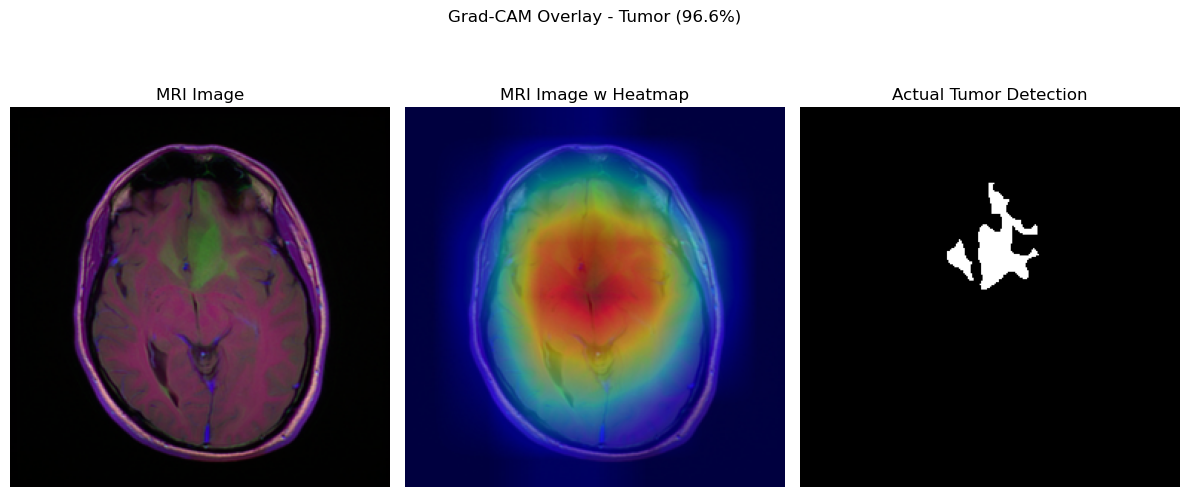

In [39]:
pred_class = y_pred.argmax(dim=1).item()
confidence = y_pred.max(dim=1).values.item() * 100
label = "Tumor" if pred_class == 1 else "No Tumor"

mri_img = Image.open(mri_path)
mask_img = Image.open(mask_path).convert('L')

fig, ax = plt.subplots(1, 3, figsize=(12, 6))
ax[0].imshow(mri_img)
ax[0].axis('off')
ax[0].set_title('MRI Image')
ax[1].imshow(mri_mask_img)
ax[1].imshow(mri_mask_img)
ax[1].imshow(mri_img)
ax[1].imshow(cam, alpha=0.5, cmap='jet')
ax[2].imshow(mri_mask_img)
ax[1].set_title("MRI Image w Heatmap")
ax[1].axis('off')
ax[2].imshow(mask_img, cmap='gray')
ax[2].axis('off')
ax[2].set_title('Actual Tumor Detection')
plt.tight_layout()
plt.suptitle(f"Grad-CAM Overlay - {label} ({confidence:.1f}%)")
plt.show()